项目介绍：本项目主要侧重于CRAG的实现和评估，用Transformer经典文献来检测搜索效果，链接：https://arxiv.org/pdf/1706.03762
 ———— CRAG：先搜索文献内容，如果无法搜索到或搜索质量较差，则联网搜索再给出答案
 ———— 评估方法：ragas，包括faithfulness、Answer Relevance、、Context Precision、Context Recall

In [31]:
import os
from dotenv import load_dotenv
import dashscope

load_dotenv()
qwen_api_key = os.getenv("DASHSCOPE_API_KEY")
# 输入通义千问 API Key（从阿里云百炼平台获取：https://dashscope.console.aliyun.com/）
if not qwen_api_key:
    raise ValueError("未找到 DASHSCOPE_API_KEY，请检查 .env 文件！")

dashscope.api_key = qwen_api_key
print("API Key 加载成功，准备就绪！")

API Key 加载成功，准备就绪！


In [ ]:
#import bs4
import os
from openai import OpenAI
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.embeddings import Embeddings
from langchain_openai import ChatOpenAI

# 自定义通义千问 Embedding 类（完善分批处理和错误防护）
class QwenEmbeddings(Embeddings):
    def __init__(self, model="text-embedding-v4", api_key=None, base_url=None, batch_size=10):
        self.model = model
        self.batch_size = batch_size  # 通义千问API强制限制最大10条/批
        self.client = OpenAI(
            api_key=api_key or dashscope.api_key or os.getenv("DASHSCOPE_API_KEY"),
            base_url=base_url or "https://dashscope.aliyuncs.com/compatible-mode/v1"
        )

    def embed_documents(self, texts):
        """批量嵌入文档 - 严格分批处理，过滤空文本"""
        texts = [text.strip() for text in texts if text.strip()]
        if not texts:
            return []
        
        embeddings = []
        for i in range(0, len(texts), self.batch_size):
            batch_texts = texts[i:i + self.batch_size]
            completion = self.client.embeddings.create(
                model=self.model,
                input=batch_texts
            )
            batch_embeddings = [item.embedding for item in completion.data]
            embeddings.extend(batch_embeddings)
        
        return embeddings
    
    def embed_query(self, text):
        """嵌入查询文本 - 处理单个文本"""
        text = text.strip()
        if not text:
            return []
        
        completion = self.client.embeddings.create(
            model=self.model,
            input=text
        )
        return completion.data[0].embedding

In [33]:
#PDF文档加载器
import os
import requests
import tempfile
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.document_loaders import PyMuPDFLoader

class PDFLoader(WebBaseLoader):
    def __init__(self, file_path):
        super().__init__(web_path=file_path)
        self.url = file_path

    def load(self):
        """
        利用 Unstructured 架构进行深度解析：可以解析图片、表格、标题等不同元素，并在元数据中保留这些信息
        """
        try:
            print(f"正在启动 PyMuPDF 解析任务: {self.url}")
            response = requests.get(self.url, timeout=15)
            response.raise_for_status()

            temp_file = tempfile.NamedTemporaryFile(delete=False, suffix=".pdf")
            temp_file.write(response.content)
            temp_path = temp_file.name
            temp_file.close()  # 重要：写入后立即关闭，释放文件锁

            try:
                # 2. 现在 PyMuPDF 可以自由访问这个文件了
                loader = PyMuPDFLoader(temp_path)
                docs = loader.load()
                print(f"解析完成！共提取 {len(docs)} 页内容。")
            finally:
                # 3. 无论解析是否成功，最后都把临时文件删掉，保持电脑干净
                if os.path.exists(temp_path):
                    os.remove(temp_path)

            return docs

        except Exception as e:
            print(f"PyMuPDF 解析失败: {e}")
            return []
        
pdf_url = "https://arxiv.org/pdf/1706.03762.pdf"
loader = PDFLoader(pdf_url)
docs = loader.load()

if docs:
    print(f"\n--- 文献解析概览 ---")
    print(f"片段总数: {len(docs)}")
        
    for i, doc in enumerate(docs[:3]):
        category = doc.metadata.get("category")
        content_preview = doc.page_content[:50].replace("\n", " ")
        print(f"片段 {i} | 类型: {category} | 内容: {content_preview}...")

正在启动 PyMuPDF 解析任务: https://arxiv.org/pdf/1706.03762.pdf
解析完成！共提取 15 页内容。

--- 文献解析概览 ---
片段总数: 15
片段 0 | 类型: None | 内容: Provided proper attribution is provided, Google he...
片段 1 | 类型: None | 内容: 1 Introduction Recurrent neural networks, long sho...
片段 2 | 类型: None | 内容: Figure 1: The Transformer - model architecture. Th...


In [34]:
import re

def clean_document_content(docs):
    """
    在分割前，对原始页面的文字进行手术级清洗
    """
    cleaned_docs = []
    for doc in docs:
        content = doc.page_content
        # 1. 过滤掉页码 (如 "Page 1 of 12" 或 单独的数字)
        content = re.sub(r'Page \d+ of \d+', '', content)
        # 2. 过滤掉常见的论文页眉干扰
        content = re.sub(r'arXiv:\d+\.\d+v\d+ \[cs\.CL\] \d+ \w+ \d+', '', content)
        # 3. 修复连字符带来的断词
        content = content.replace("-\n", "")
        # 4. 将多个换行符替换为标准分段，去除多余空格
        content = re.sub(r'\n+', '\n', content)
        content = content.strip()
        
        # 只保留有实质内容的页面
        if len(content) > 10:
            doc.page_content = content
            cleaned_docs.append(doc)
            
    print(f"清洗完成：已处理 {len(cleaned_docs)} 页内容")
    return cleaned_docs

cleaned_docs = clean_document_content(docs)

清洗完成：已处理 15 页内容


In [35]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def get_text_chunks(docs, chunk_size=600, chunk_overlap=60):
    """
    函数式写法：输入原始文档，返回切割好的块
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", "。", "！", "？", " ", ""]
    )
    
    chunks = splitter.split_documents(docs)
    print(f"已切分为 {len(chunks)} 个片段")
    return chunks

chunks = get_text_chunks(cleaned_docs, chunk_size=600, chunk_overlap=60)

已切分为 78 个片段


In [36]:

# Embed - 确保使用带分批处理的QwenEmbeddings
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=QwenEmbeddings(
        model="text-embedding-v4",
        api_key=os.environ["DASHSCOPE_API_KEY"],
        base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
        batch_size=10  # 明确指定批量大小，与API限制一致
    )
)

retriever = vectorstore.as_retriever()

In [ ]:
# 生成答案
from langchain.prompts import PromptTemplate

def get_answer_from_pdf(query, retriever):
    prompt = PromptTemplate(
        input_variables=["context", "question"],
        template="""你是一个严谨的学术助手。
        请严格根据下方提供的【参考资料】来回答用户的问题。
        要求：
        1. 只能使用资料中的事实，严禁发挥。
        2. 如果资料未提及，请回答“资料中未找到相关内容”。
        3. 涉及计算复杂度或具体数值（如 d_model）时，必须完全与原文一致
        参考资料：{context}
        待回答的问题：{question}
        请用专业、简洁的中文回答："""
    )

    llm = ChatOpenAI(
        model_name="qwen-turbo",
        temperature=0,
        base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
        api_key=os.environ["DASHSCOPE_API_KEY"],
        max_tokens=1024
    )
    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain: Retriever -> Format -> Prompt -> LLM -> Output Parser
    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )
    answer = rag_chain.invoke(query)
    return answer   

query = input("请输入你的问题：")
answer = get_answer_from_pdf(query, retriever)
print("答案：", answer)

答案： 资料中未找到相关内容。


In [47]:
# Ragas 评测：使用 5 项核心指标全面评估 RAG 系统
import os
import pandas as pd
from datasets import Dataset
from ragas import evaluate
from langchain_openai import ChatOpenAI
from ragas.metrics import (
    Faithfulness,
    AnswerRelevancy,
    LLMContextRecall,
    LLMContextPrecisionWithReference,
    AnswerCorrectness,
)

# 导入统一的评测集定义
from evaluation_dataset import eval_questions_50, eval_ground_truths_50

# 1. 定义"裁判员" LLM
evaluator_llm = ChatOpenAI(
    model_name="qwen-max",
    api_key=os.environ["DASHSCOPE_API_KEY"],
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    temperature=0,
    max_tokens=1024,
)

# 2. 定义 Embeddings
evaluator_embeddings = QwenEmbeddings(
    model="text-embedding-v4",
    api_key=os.environ["DASHSCOPE_API_KEY"],
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    batch_size=10,
)

# 3. 实例化 5 项核心指标对象
metrics = [
    Faithfulness(llm=evaluator_llm),                    # 忠实性：答案是否基于检索上下文
    AnswerRelevancy(llm=evaluator_llm),                # 答案相关性：答案与问题的相关程度
    LLMContextRecall(llm=evaluator_llm),               # 上下文召回率：检索上下文覆盖标准答案的程度
    LLMContextPrecisionWithReference(llm=evaluator_llm),  # 上下文精确度：检索上下文的相关程度
    AnswerCorrectness(llm=evaluator_llm),              # 答案正确性：答案与标准答案的一致性
]

print("="*80)
print("📊 Ragas 评测指标说明")
print("="*80)
print("1. Faithfulness (忠实性): 答案是否忠实于检索到的上下文，无幻觉")
print("2. AnswerRelevancy (答案相关性): 答案是否直接回答了问题")
print("3. ContextRecall (上下文召回率): 检索上下文是否覆盖标准答案的关键信息")
print("4. ContextPrecision (上下文精确度): 检索上下文中有多少是相关的")
print("5. AnswerCorrectness (答案正确性): 答案与标准答案的语义一致程度")
print("="*80 + "\n")

def answer_question_for_eval(main_question: str):
    """运行 baseline RAG 流程，并返回答案与检索上下文"""
    docs = retriever.invoke(main_question)
    docs = [doc for doc in docs if getattr(doc, "page_content", "").strip()]
    response = get_answer_from_pdf(main_question, retriever)
    retrieved_contexts = [doc.page_content for doc in docs]
    return response, retrieved_contexts

def build_ragas_dataset(eval_questions: list, eval_ground_truths: list, limit: int | None = None, indices: list | None = None):
    """
    构造 Ragas 评测数据集
    
    参数：
    - eval_questions, eval_ground_truths: 问题和回答列表
    - limit: 限制数量（随机采样前 limit 个）
    - indices: 指定题目索引列表（优先级高于 limit）
    """
    # 优先使用 indices，否则用 limit，否则全量
    if indices is not None:
        selected_questions = [eval_questions[i] for i in indices]
        selected_truths = [eval_ground_truths[i] for i in indices]
    elif limit is not None:
        selected_questions = eval_questions[:limit]
        selected_truths = eval_ground_truths[:limit]
    else:
        selected_questions = eval_questions
        selected_truths = eval_ground_truths
    
    records = []
    for idx, (user_input, reference) in enumerate(zip(selected_questions, selected_truths), start=1):
        print(f"[{idx}/{len(selected_questions)}] 正在生成 baseline 回答与上下文: {user_input}")
        response, retrieved_contexts = answer_question_for_eval(user_input)
        records.append({
            "user_input": user_input,
            "response": response,
            "reference": reference,
            "retrieved_contexts": retrieved_contexts,
        })

    dataset = Dataset.from_list(records)
    return dataset, pd.DataFrame(records)

def run_ragas_evaluation(limit: int | None = None, evaluator_model_name: str = "qwen-max", indices: list | None = None):
    """
    执行 5 项核心 Ragas 指标评测
    
    参数：
    - limit: 随机采样前 limit 个题目
    - evaluator_model_name: 评测模型名称
    - indices: 指定要评测的题目索引列表（优先级高于 limit）
    """
    eval_dataset, eval_records_df = build_ragas_dataset(
        eval_questions_50,
        eval_ground_truths_50,
        limit=limit,
        indices=indices,
    )

    print("🧪 Ragas 正在进行语义对齐与逻辑打分...")
    eval_result = evaluate(
        dataset=eval_dataset,
        metrics=metrics,
        llm=evaluator_llm,
        embeddings=evaluator_embeddings,
        raise_exceptions=False,
        show_progress=True,
    )

    score_df = eval_result.to_pandas()
    metric_cols = [
        col
        for col in [
            "faithfulness",
            "answer_relevancy",
            "context_recall",
            "llm_context_precision_with_reference",
            "answer_correctness",
        ]
        if col in score_df.columns
    ]
    merged_df = pd.concat([eval_records_df.reset_index(drop=True), score_df[metric_cols].reset_index(drop=True)], axis=1)
    return merged_df

📊 Ragas 评测指标说明
1. Faithfulness (忠实性): 答案是否忠实于检索到的上下文，无幻觉
2. AnswerRelevancy (答案相关性): 答案是否直接回答了问题
3. ContextRecall (上下文召回率): 检索上下文是否覆盖标准答案的关键信息
4. ContextPrecision (上下文精确度): 检索上下文中有多少是相关的
5. AnswerCorrectness (答案正确性): 答案与标准答案的语义一致程度



C:\Users\59118\AppData\Local\Temp\ipykernel_54596\2029107766.py:7: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import (
C:\Users\59118\AppData\Local\Temp\ipykernel_54596\2029107766.py:7: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import (
C:\Users\59118\AppData\Local\Temp\ipykernel_54596\2029107766.py:7: DeprecationWarning: Importing LLMContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextRecall
  from ragas.metrics import (
C:\Users\59118\AppData\Local\Temp\ipykernel_54596\

In [48]:
# 分层采样函数
def sample_stratified_evaluation(total_samples: int = 5):
    """
    分层采样：确保小样本包含三种题型
    
    题型分布：
    - Q1-38 (76%): 基础知识题 -> 采样约 76% 的样本
    - Q39-45 (14%): 复杂/困难题 -> 采样约 14% 的样本  
    - Q46-50 (10%): 推理题 -> 采样约 10% 的样本
    
    示例：5个样本会采样为 [4基础, 1复杂, 0推理] 或类似分配
    """
    import numpy as np
    
    # 定义题型分组
    basic_indices = list(range(0, 38))  # Q1-38
    complex_indices = list(range(38, 45))  # Q39-45
    reasoning_indices = list(range(45, 50))  # Q46-50
    
    # 按比例分配样本数量
    basic_count = max(1, int(total_samples * 0.76))
    complex_count = max(1, int(total_samples * 0.14))
    reasoning_count = max(1, int(total_samples * 0.10))
    
    # 调整使总和等于 total_samples（处理四舍五入）
    total_allocated = basic_count + complex_count + reasoning_count
    if total_allocated > total_samples:
        if reasoning_count > 0:
            reasoning_count -= (total_allocated - total_samples)
        elif complex_count > 0:
            complex_count -= (total_allocated - total_samples)
        else:
            basic_count -= (total_allocated - total_samples)
    elif total_allocated < total_samples:
        basic_count += (total_samples - total_allocated)
    
    # 随机采样
    np.random.seed(42)  # 固定随机种子，确保可重复性
    sampled_indices = (
        np.random.choice(basic_indices, size=basic_count, replace=False).tolist() +
        np.random.choice(complex_indices, size=complex_count, replace=False).tolist() +
        np.random.choice(reasoning_indices, size=reasoning_count, replace=False).tolist()
    )
    
    print(f"✅ 分层采样完成：共 {total_samples} 题")
    print(f"   - 基础知识题: {basic_count} 题（Q1-38）")
    print(f"   - 复杂/困难题: {complex_count} 题（Q39-45）")
    print(f"   - 推理题: {reasoning_count} 题（Q46-50）")
    print(f"   - 采样题号: {sorted(sampled_indices)}\n")
    
    return sorted(sampled_indices)

# ========== 小样本评测：分层采样（推荐）==========
# 验证评测集已加载
assert len(eval_questions_50) == 50
assert len(eval_ground_truths_50) == 50
print(f"✅ 已加载 {len(eval_questions_50)} 个问题和 {len(eval_ground_truths_50)} 个标准答案。（包含5个陷阱题/推理题，占比10%）\n")

# 分层采样
eval_indices = sample_stratified_evaluation(total_samples=5)

# 运行小样本评测
sample_report = run_ragas_evaluation(indices=eval_indices)

# ========== 全量评测：注释掉上面的代码，取消注释下面这行 ==========
# full_report = run_ragas_evaluation()

# 查看结果时可执行：
# display(sample_report.head())
# display(full_report.head())

✅ 已加载 50 个问题和 50 个标准答案。（包含5个陷阱题/推理题，占比10%）

✅ 分层采样完成：共 5 题
   - 基础知识题: 3 题（Q1-38）
   - 复杂/困难题: 1 题（Q39-45）
   - 推理题: 1 题（Q46-50）
   - 采样题号: [4, 33, 36, 43, 49]

[1/5] 正在生成 baseline 回答与上下文: Transformer 在每个子层外部使用了哪两种稳定训练的结构？
[2/5] 正在生成 baseline 回答与上下文: 论文报告的 Transformer big 在英德任务上的 BLEU 分数是多少？
[3/5] 正在生成 baseline 回答与上下文: 论文在推理阶段如何平滑最终模型参数？
[4/5] 正在生成 baseline 回答与上下文: 受限自注意力中两个位置之间的最大路径长度是多少？
[5/5] 正在生成 baseline 回答与上下文: 英德任务在数据预处理时采用了什么分词方式？
🧪 Ragas 正在进行语义对齐与逻辑打分...


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")
Evaluating:   4%|▍         | 1/25 [00:10<04:00, 10.02s/it]d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")
Evaluating:  20%|██        | 5/25 [00:21<01:05,  3.27s/it]d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")
Evaluating:  44%|████▍     | 11/25 [00:28<00:25,  1.84s/it]d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token 

In [46]:
from evaluation_dataset import eval_questions_50, eval_ground_truths_50

def sample_stratified_evaluation(total_samples: int = 5):
    """
    分层采样：确保小样本包含三种题型
    
    题型分布：
    - Q1-38 (76%): 基础知识题 -> 采样约 76% 的样本
    - Q39-45 (14%): 复杂/困难题 -> 采样约 14% 的样本  
    - Q46-50 (10%): 推理题 -> 采样约 10% 的样本
    
    示例：5个样本会采样为 [4基础, 1复杂, 0推理] 或类似分配
    """
    import numpy as np
    
    # 定义题型分组
    basic_indices = list(range(0, 38))  # Q1-38
    complex_indices = list(range(38, 45))  # Q39-45
    reasoning_indices = list(range(45, 50))  # Q46-50
    
    # 按比例分配样本数量
    basic_count = max(1, int(total_samples * 0.76))
    complex_count = max(1, int(total_samples * 0.14))
    reasoning_count = max(1, int(total_samples * 0.10))
    
    # 调整使总和等于 total_samples（处理四舍五入）
    total_allocated = basic_count + complex_count + reasoning_count
    if total_allocated > total_samples:
        if reasoning_count > 0:
            reasoning_count -= (total_allocated - total_samples)
        elif complex_count > 0:
            complex_count -= (total_allocated - total_samples)
        else:
            basic_count -= (total_allocated - total_samples)
    elif total_allocated < total_samples:
        basic_count += (total_samples - total_allocated)
    
    # 随机采样
    sampled_indices = (
        np.random.choice(basic_indices, size=basic_count, replace=False).tolist() +
        np.random.choice(complex_indices, size=complex_count, replace=False).tolist() +
        np.random.choice(reasoning_indices, size=reasoning_count, replace=False).tolist()
    )
    
    print(f"✅ 分层采样完成：共 {total_samples} 题")
    print(f"   - 基础知识题: {basic_count} 题（Q1-38）")
    print(f"   - 复杂/困难题: {complex_count} 题（Q39-45）")
    print(f"   - 推理题: {reasoning_count} 题（Q46-50）")
    print(f"   - 采样题号: {sorted(sampled_indices)}\n")
    
    return sorted(sampled_indices)

# 选择评测题号（分层采样：确保三种类型都有）
eval_indices = sample_stratified_evaluation(total_samples=5)

# 对应的问题和答案
eval_questions_sample = [eval_questions_50[i] for i in eval_indices]
eval_ground_truths_sample = [eval_ground_truths_50[i] for i in eval_indices]

✅ 分层采样完成：共 5 题
   - 基础知识题: 3 题（Q1-38）
   - 复杂/困难题: 1 题（Q39-45）
   - 推理题: 1 题（Q46-50）
   - 采样题号: [14, 27, 30, 38, 48]



In [49]:
# 显示评测结果
metric_cols = [
    col
    for col in [
        "faithfulness",
        "answer_relevancy",
        "context_recall",
        "llm_context_precision_with_reference",
        "answer_correctness",  # 新增：答案正确性
    ]
    if col in sample_report.columns
]

print("="*80)
print("📊 评测结果汇总")
print("="*80)
print(f"\n{'指标':<30} {'平均分':>10} {'说明':<40}")
print("-"*80)
print(f"{'Faithfulness (忠实性)':<30} {sample_report['faithfulness'].mean():>10.4f} 答案是否基于检索上下文，无幻觉")
print(f"{'Answer Relevancy (答案相关性)':<30} {sample_report['answer_relevancy'].mean():>10.4f} 答案与问题的相关程度")
print(f"{'Context Recall (上下文召回)':<30} {sample_report['context_recall'].mean():>10.4f} 检索上下文覆盖标准答案的程度")
print(f"{'Context Precision (上下文精度)':<30} {sample_report['llm_context_precision_with_reference'].mean():>10.4f} 检索上下文的相关程度")
print(f"{'Answer Correctness (答案正确性)':<30} {sample_report['answer_correctness'].mean():>10.4f} 答案与标准答案的一致性")
print("-"*80)
print(f"{'总体平均分':<30} {sample_report[metric_cols].mean().mean():>10.4f}")
print("="*80)

# 显示详细结果
diag_cols = [col for col in [
    "user_input",
    "reference",
    "response",
    "faithfulness",
    "answer_relevancy",
    "context_recall",
    "llm_context_precision_with_reference",
    "answer_correctness",  # 新增
 ] if col in sample_report.columns]

print("\n📝 详细结果（前5条）：")
display(sample_report[diag_cols].head(5))

📊 评测结果汇总

指标                                    平均分 说明                                      
--------------------------------------------------------------------------------
Faithfulness (忠实性)                 0.7333 答案是否基于检索上下文，无幻觉
Answer Relevancy (答案相关性)           0.7182 答案与问题的相关程度
Context Recall (上下文召回)             0.8000 检索上下文覆盖标准答案的程度
Context Precision (上下文精度)          0.8000 检索上下文的相关程度
Answer Correctness (答案正确性)         0.7327 答案与标准答案的一致性
--------------------------------------------------------------------------------
总体平均分                              0.7568

📝 详细结果（前5条）：


,user_input,reference,response,faithfulness,answer_relevancy,context_recall,llm_context_precision_with_reference,answer_correctness
0,Transformer 在每个子层外部使用了哪两种稳定训练的结构？,每个子层外部都使用残差连接，并在残差相加后进行层归一化。,Transformer 在每个子层外部使用了残差连接和层归一化来稳定训练。,0.666667,0.931187,1.0,1.0,0.821387
1,论文报告的 Transformer big 在英德任务上的 BLEU 分数是多少？,论文报告的 Transformer big 在 WMT 2014 英德任务上达到 28.4 ...,论文报告的 Transformer big 在英德任务上的 BLEU 分数是 28.4。,1.000000,0.833902,1.0,1.0,0.983059
2,论文在推理阶段如何平滑最终模型参数？,论文通过平均最后 5 个 checkpoint 的参数来得到最终模型。,资料中未找到相关内容。,0.000000,0.000000,0.0,0.0,0.051114
3,受限自注意力中两个位置之间的最大路径长度是多少？,受限自注意力中两个位置之间的最大路径长度是 O(n/r)。,受限自注意力中两个位置之间的最大路径长度是 O(n/r)。,1.000000,0.978429,1.0,1.0,1.000000
4,英德任务在数据预处理时采用了什么分词方式？,英德任务使用了源语言和目标语言共享的 byte-pair encoding 分词方案。,英德任务在数据预处理时采用了字节对编码（byte-pair encoding）。,1.000000,0.847237,1.0,1.0,0.808172


## Chunk Size 实验对比

本节将对不同的 chunk_size 进行实验对比，以找出最佳的切分参数。

**实验设计：**
- 测试 5 种不同的 chunk_size: 200, 400, 600, 800, 1000
- chunk_overlap 固定为 chunk_size 的 10%
- 使用相同的评测集（前 10 个问题进行快速对比）
- 对比指标：faithfulness, answer_relevancy, context_recall, context_precision

In [43]:
import pandas as pd
from langchain_community.vectorstores import Chroma
import tempfile
import shutil

def create_rag_system_with_chunk_size(chunk_size, chunk_overlap_ratio=0.1):
    """
    创建指定 chunk_size 的 RAG 系统
    
    Args:
        chunk_size: 切分大小
        chunk_overlap_ratio: 重叠比例（默认 10%）
    
    Returns:
        retriever: 检索器
        num_chunks: 切分后的文档数量
    """
    chunk_overlap = int(chunk_size * chunk_overlap_ratio)
    
    # 1. 文本切分
    chunks = get_text_chunks(cleaned_docs, chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    
    # 2. 创建临时向量存储路径（避免冲突）
    temp_dir = tempfile.mkdtemp(prefix=f"chroma_chunk_{chunk_size}_")
    
    # 3. 创建向量存储
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=QwenEmbeddings(
            model="text-embedding-v4",
            api_key=os.environ["DASHSCOPE_API_KEY"],
            base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
            batch_size=10
        ),
        persist_directory=temp_dir
    )
    
    retriever = vectorstore.as_retriever()
    
    return retriever, len(chunks), temp_dir

def evaluate_with_chunk_size(chunk_size, eval_questions, eval_ground_truths, limit=10):
    """
    使用指定 chunk_size 评估 RAG 系统
    
    Args:
        chunk_size: 切分大小
        eval_questions: 问题列表
        eval_ground_truths: 标准答案列表
        limit: 测试问题数量
    
    Returns:
        result_df: 评估结果 DataFrame
    """
    print(f"\n{'='*60}")
    print(f"🔬 正在测试 chunk_size = {chunk_size}")
    print(f"{'='*60}")
    
    # 创建 RAG 系统
    test_retriever, num_chunks, temp_dir = create_rag_system_with_chunk_size(chunk_size)
    print(f"✅ 已切分为 {num_chunks} 个文档块")
    
    # 评估时临时切换到本次实验的检索器
    original_retriever = globals().get("retriever")
    globals()["retriever"] = test_retriever
    
    try:
        eval_dataset, eval_records_df = build_ragas_dataset(
            eval_questions[:limit],
            eval_ground_truths[:limit],
            limit=limit,
        )

        # 运行 Ragas 评估
        print("🧪 Ragas 正在进行语义对齐与逻辑打分...")
        eval_result = evaluate(
            dataset=eval_dataset,
            metrics=metrics,
            llm=evaluator_llm,
            embeddings=evaluator_embeddings,
            raise_exceptions=False,
            show_progress=False,  # 减少输出
        )

        score_df = eval_result.to_pandas()

        # 合并结果
        metric_cols = [col for col in ["faithfulness", "answer_relevancy", "context_recall", "llm_context_precision_with_reference"] if col in score_df.columns]
        merged_df = pd.concat([eval_records_df.reset_index(drop=True), score_df[metric_cols].reset_index(drop=True)], axis=1)
    finally:
        if original_retriever is not None:
            globals()["retriever"] = original_retriever
        # 清理临时目录
        shutil.rmtree(temp_dir, ignore_errors=True)
    
    return merged_df, num_chunks

# 测试单个 chunk_size（用于调试）
test_chunk_size = 400
test_result, test_num_chunks = evaluate_with_chunk_size(
    test_chunk_size, 
    eval_questions_50, 
    eval_ground_truths_50, 
    limit=3
)
print(f"\n✅ 测试完成！chunk_size={test_chunk_size}, 文档块数={test_num_chunks}")
display(test_result[[col for col in ["user_input", "faithfulness", "answer_relevancy", "llm_context_precision_with_reference"] if col in test_result.columns]])


🔬 正在测试 chunk_size = 400
已切分为 118 个片段
✅ 已切分为 118 个文档块
[1/3] 正在生成 baseline 回答与上下文: Transformer 模型采用了什么总体架构？
[2/3] 正在生成 baseline 回答与上下文: 原始 Transformer 中编码器和解码器各堆叠了多少层？
[3/3] 正在生成 baseline 回答与上下文: 编码器每一层包含哪两个主要子层？
🧪 Ragas 正在进行语义对齐与逻辑打分...


d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")



✅ 测试完成！chunk_size=400, 文档块数=118


,user_input,faithfulness,answer_relevancy,llm_context_precision_with_reference
0,Transformer 模型采用了什么总体架构？,1.0,0.711197,1.0
1,原始 Transformer 中编码器和解码器各堆叠了多少层？,1.0,0.845646,0.5
2,编码器每一层包含哪两个主要子层？,1.0,0.871657,0.5


In [44]:
# 批量测试多个 chunk_size
import time

# 定义实验参数
chunk_sizes_to_test = [200, 400, 600, 800, 1000]
num_test_questions = 10  # 使用前 10 个问题进行快速对比

# 存储结果
results_summary = []
all_results = {}

print("🚀 开始批量 chunk_size 实验")
print(f"📊 将测试 {len(chunk_sizes_to_test)} 种不同的 chunk_size")
print(f"❓ 每个配置使用 {num_test_questions} 个问题进行评测")
print(f"⏰ 预计总耗时: 约 {len(chunk_sizes_to_test) * num_test_questions * 2 / 60:.1f} 分钟")

start_time = time.time()

for chunk_size in chunk_sizes_to_test:
    try:
        result_df, num_chunks = evaluate_with_chunk_size(
            chunk_size,
            eval_questions_50,
            eval_ground_truths_50,
            limit=num_test_questions
        )
        
        # 计算平均指标
        metric_cols = [col for col in ["faithfulness", "answer_relevancy", "context_recall", "llm_context_precision_with_reference"] if col in result_df.columns]
        avg_scores = result_df[metric_cols].mean()
        
        # 存储结果
        summary = {
            "chunk_size": chunk_size,
            "num_chunks": num_chunks,
            "faithfulness": avg_scores.get("faithfulness", 0),
            "answer_relevancy": avg_scores.get("answer_relevancy", 0),
            "context_recall": avg_scores.get("context_recall", 0),
            "context_precision": avg_scores.get("llm_context_precision_with_reference", 0),
            "avg_score": avg_scores.mean()
        }
        results_summary.append(summary)
        all_results[chunk_size] = result_df
        
        print(f"✅ chunk_size={chunk_size} 完成 | 平均分: {summary['avg_score']:.4f}")
        
    except Exception as e:
        print(f"❌ chunk_size={chunk_size} 失败: {str(e)}")
        import traceback
        traceback.print_exc()

total_time = time.time() - start_time
print(f"\n🎉 所有实验完成！总耗时: {total_time / 60:.2f} 分钟")

# 创建汇总表
summary_df = pd.DataFrame(results_summary)
print("\n📊 实验结果汇总:")
display(summary_df)

🚀 开始批量 chunk_size 实验
📊 将测试 5 种不同的 chunk_size
❓ 每个配置使用 10 个问题进行评测
⏰ 预计总耗时: 约 1.7 分钟

🔬 正在测试 chunk_size = 200
已切分为 257 个片段
✅ 已切分为 257 个文档块
[1/10] 正在生成 baseline 回答与上下文: Transformer 模型采用了什么总体架构？
[2/10] 正在生成 baseline 回答与上下文: 原始 Transformer 中编码器和解码器各堆叠了多少层？
[3/10] 正在生成 baseline 回答与上下文: 编码器每一层包含哪两个主要子层？
[4/10] 正在生成 baseline 回答与上下文: 解码器每一层相比编码器额外多了什么子层？
[5/10] 正在生成 baseline 回答与上下文: Transformer 在每个子层外部使用了哪两种稳定训练的结构？
[6/10] 正在生成 baseline 回答与上下文: Scaled Dot-Product Attention 的计算公式是什么？
[7/10] 正在生成 baseline 回答与上下文: 为什么注意力分数要除以 sqrt(d_k)？
[8/10] 正在生成 baseline 回答与上下文: base 版 Transformer 使用多少个注意力头？
[9/10] 正在生成 baseline 回答与上下文: Transformer base 配置中的 d_model 取值是多少？
[10/10] 正在生成 baseline 回答与上下文: 在 8 头设置下，每个头的 d_k 和 d_v 分别是多少？
🧪 Ragas 正在进行语义对齐与逻辑打分...


d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")
d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")
d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")
d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")
d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: 

✅ chunk_size=200 完成 | 平均分: 0.7700

🔬 正在测试 chunk_size = 400
已切分为 118 个片段
✅ 已切分为 118 个文档块
[1/10] 正在生成 baseline 回答与上下文: Transformer 模型采用了什么总体架构？
[2/10] 正在生成 baseline 回答与上下文: 原始 Transformer 中编码器和解码器各堆叠了多少层？
[3/10] 正在生成 baseline 回答与上下文: 编码器每一层包含哪两个主要子层？
[4/10] 正在生成 baseline 回答与上下文: 解码器每一层相比编码器额外多了什么子层？
[5/10] 正在生成 baseline 回答与上下文: Transformer 在每个子层外部使用了哪两种稳定训练的结构？
[6/10] 正在生成 baseline 回答与上下文: Scaled Dot-Product Attention 的计算公式是什么？
[7/10] 正在生成 baseline 回答与上下文: 为什么注意力分数要除以 sqrt(d_k)？
[8/10] 正在生成 baseline 回答与上下文: base 版 Transformer 使用多少个注意力头？
[9/10] 正在生成 baseline 回答与上下文: Transformer base 配置中的 d_model 取值是多少？
[10/10] 正在生成 baseline 回答与上下文: 在 8 头设置下，每个头的 d_k 和 d_v 分别是多少？
🧪 Ragas 正在进行语义对齐与逻辑打分...


d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")
d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")
d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")
d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")
d:\project\CRAG\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:406: UserWarning: Unexpected type for token usage: 

✅ chunk_size=400 完成 | 平均分: 0.8189

🔬 正在测试 chunk_size = 600
已切分为 78 个片段
✅ 已切分为 78 个文档块
[1/10] 正在生成 baseline 回答与上下文: Transformer 模型采用了什么总体架构？
[2/10] 正在生成 baseline 回答与上下文: 原始 Transformer 中编码器和解码器各堆叠了多少层？
[3/10] 正在生成 baseline 回答与上下文: 编码器每一层包含哪两个主要子层？
[4/10] 正在生成 baseline 回答与上下文: 解码器每一层相比编码器额外多了什么子层？
[5/10] 正在生成 baseline 回答与上下文: Transformer 在每个子层外部使用了哪两种稳定训练的结构？
[6/10] 正在生成 baseline 回答与上下文: Scaled Dot-Product Attention 的计算公式是什么？
[7/10] 正在生成 baseline 回答与上下文: 为什么注意力分数要除以 sqrt(d_k)？
[8/10] 正在生成 baseline 回答与上下文: base 版 Transformer 使用多少个注意力头？
[9/10] 正在生成 baseline 回答与上下文: Transformer base 配置中的 d_model 取值是多少？
[10/10] 正在生成 baseline 回答与上下文: 在 8 头设置下，每个头的 d_k 和 d_v 分别是多少？
🧪 Ragas 正在进行语义对齐与逻辑打分...


...

✅ chunk_size=600 完成 | 平均分: 0.8591

🔬 正在测试 chunk_size = 800
已切分为 60 个片段
✅ 已切分为 60 个文档块
[1/10] 正在生成 baseline 回答与上下文: Transformer 模型采用了什么总体架构？
[2/10] 正在生成 baseline 回答与上下文: 原始 Transformer 中编码器和解码器各堆叠了多少层？
[3/10] 正在生成 baseline 回答与上下文: 编码器每一层包含哪两个主要子层？
[4/10] 正在生成 baseline 回答与上下文: 解码器每一层相比编码器额外多了什么子层？
[5/10] 正在生成 baseline 回答与上下文: Transformer 在每个子层外部使用了哪两种稳定训练的结构？
[6/10] 正在生成 baseline 回答与上下文: Scaled Dot-Product Attention 的计算公式是什么？
[7/10] 正在生成 baseline 回答与上下文: 为什么注意力分数要除以 sqrt(d_k)？
[8/10] 正在生成 baseline 回答与上下文: base 版 Transformer 使用多少个注意力头？
❌ chunk_size=800 失败: Error code: 400 - {'error': {'message': 'Access denied, please make sure your account is in good standing. For details, see: https://help.aliyun.com/zh/model-studio/error-code#overdue-payment', 'type': 'Arrearage', 'param': None, 'code': 'Arrearage'}, 'id': '26287e2d-b4a2-907e-b099-9f2b163353b0', 'request_id': '26287e2d-b4a2-907e-b099-9f2b163353b0'}

🔬 正在测试 chunk_size = 1000
已切分为 49 个片段


Traceback (most recent call last):
  File "C:\Users\59118\AppData\Local\Temp\ipykernel_54596\212670031.py", line 21, in <module>
    result_df, num_chunks = evaluate_with_chunk_size(
                            ~~~~~~~~~~~~~~~~~~~~~~~~^
        chunk_size,
        ^^^^^^^^^^^
    ...<2 lines>...
        limit=num_test_questions
        ^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\59118\AppData\Local\Temp\ipykernel_54596\1638790294.py", line 68, in evaluate_with_chunk_size
    eval_dataset, eval_records_df = build_ragas_dataset(
                                    ~~~~~~~~~~~~~~~~~~~^
        eval_questions[:limit],
        ^^^^^^^^^^^^^^^^^^^^^^^
        eval_ground_truths[:limit],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^
        limit=limit,
        ^^^^^^^^^^^^
    )
    ^
  File "C:\Users\59118\AppData\Local\Temp\ipykernel_54596\4062864981.py", line 57, in build_ragas_dataset
    response, retrieved_contexts = answer_question_for_eval(user_input)
                                

❌ chunk_size=1000 失败: Error code: 400 - {'error': {'message': 'Access denied, please make sure your account is in good standing. For details, see: https://help.aliyun.com/zh/model-studio/error-code#overdue-payment', 'type': 'Arrearage', 'param': None, 'code': 'Arrearage'}, 'id': '88fc294a-8927-97be-8e97-f5fa578fcf1e', 'request_id': '88fc294a-8927-97be-8e97-f5fa578fcf1e'}

🎉 所有实验完成！总耗时: 7.70 分钟

📊 实验结果汇总:


Traceback (most recent call last):
  File "C:\Users\59118\AppData\Local\Temp\ipykernel_54596\212670031.py", line 21, in <module>
    result_df, num_chunks = evaluate_with_chunk_size(
                            ~~~~~~~~~~~~~~~~~~~~~~~~^
        chunk_size,
        ^^^^^^^^^^^
    ...<2 lines>...
        limit=num_test_questions
        ^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\59118\AppData\Local\Temp\ipykernel_54596\1638790294.py", line 60, in evaluate_with_chunk_size
    test_retriever, num_chunks, temp_dir = create_rag_system_with_chunk_size(chunk_size)
                                           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "C:\Users\59118\AppData\Local\Temp\ipykernel_54596\1638790294.py", line 27, in create_rag_system_with_chunk_size
    vectorstore = Chroma.from_documents(
        documents=chunks,
    ...<6 lines>...
        persist_directory=temp_dir
    )
  File "d:\project\CRAG\.venv\Lib\site-packages\langchain_community\vectorstores\chroma.

,chunk_size,num_chunks,faithfulness,answer_relevancy,context_recall,context_precision,avg_score
0,200,257,0.825,0.813406,0.9,0.541667,0.770018
1,400,118,0.800,0.775520,1.0,0.700000,0.818880
2,600,78,0.875,0.886485,0.9,0.775000,0.859121


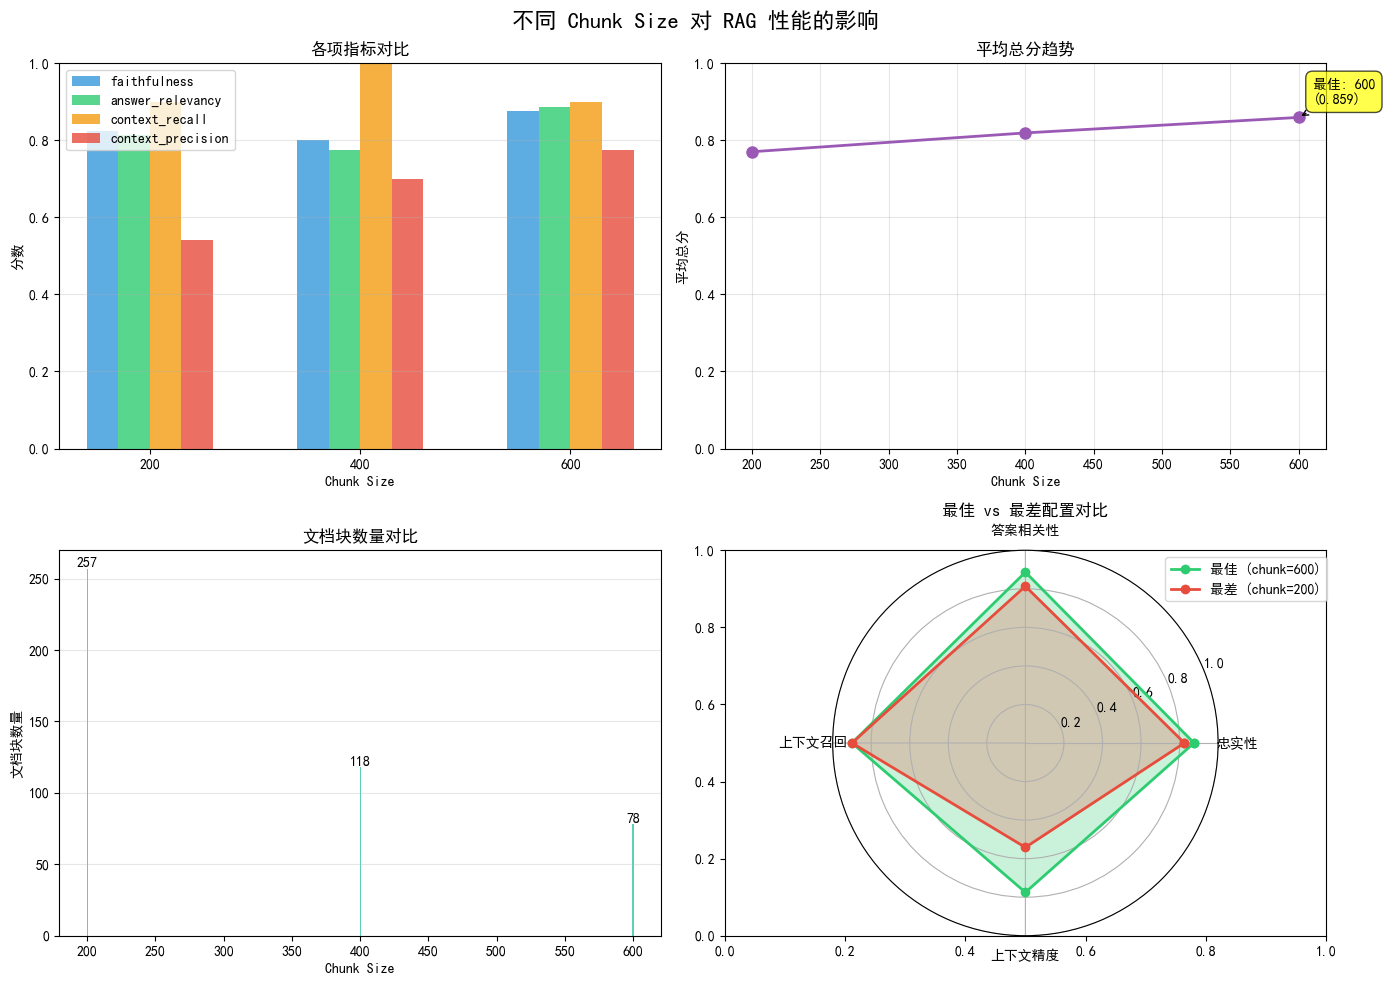


📊 实验结论

✅ 最佳配置: chunk_size = 600
   - 平均总分: 0.8591
   - 文档块数: 78

📈 各项指标最佳值:
   - faithfulness: 0.8750 (chunk_size=600)
   - answer_relevancy: 0.8865 (chunk_size=600)
   - context_recall: 1.0000 (chunk_size=400)
   - context_precision: 0.7750 (chunk_size=600)

💡 建议:
   - 中等大小的 chunk_size 取得了最佳平衡
     * 在精确性和上下文完整性之间取得了较好的平衡


In [45]:
# 可视化对比结果
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 中文字体
matplotlib.rcParams['axes.unicode_minus'] = False  # 负号显示

# 创建图表
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('不同 Chunk Size 对 RAG 性能的影响', fontsize=16, fontweight='bold')

# 1. 各项指标对比（柱状图）
ax1 = axes[0, 0]
x = range(len(summary_df))
width = 0.15

metrics = ['faithfulness', 'answer_relevancy', 'context_recall', 'context_precision']
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    if metric in summary_df.columns:
        ax1.bar([xi + i * width for xi in x], summary_df[metric], width, label=metric, color=color, alpha=0.8)

ax1.set_xlabel('Chunk Size')
ax1.set_ylabel('分数')
ax1.set_title('各项指标对比')
ax1.set_xticks([xi + width * 1.5 for xi in x])
ax1.set_xticklabels(summary_df['chunk_size'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# 2. 平均总分对比（折线图）
ax2 = axes[0, 1]
ax2.plot(summary_df['chunk_size'], summary_df['avg_score'], marker='o', linewidth=2, markersize=8, color='#9b59b6')
ax2.set_xlabel('Chunk Size')
ax2.set_ylabel('平均总分')
ax2.set_title('平均总分趋势')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

# 标注最高分
best_idx = summary_df['avg_score'].idxmax()
best_chunk = summary_df.loc[best_idx, 'chunk_size']
best_score = summary_df.loc[best_idx, 'avg_score']
ax2.annotate(f'最佳: {best_chunk}\n({best_score:.3f})', 
             xy=(best_chunk, best_score), 
             xytext=(10, 10), textcoords='offset points',
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

# 3. 文档块数量变化
ax3 = axes[1, 0]
ax3.bar(summary_df['chunk_size'], summary_df['num_chunks'], color='#1abc9c', alpha=0.7)
ax3.set_xlabel('Chunk Size')
ax3.set_ylabel('文档块数量')
ax3.set_title('文档块数量对比')
ax3.grid(axis='y', alpha=0.3)

# 添加数值标签
for i, v in enumerate(summary_df['num_chunks']):
    ax3.text(summary_df['chunk_size'][i], v + 1, str(v), ha='center', fontweight='bold')

# 4. 综合性能雷达图
ax4 = axes[1, 1]
categories = ['忠实性', '答案相关性', '上下文召回', '上下文精度']
N = len(categories)

# 选择最佳和最差的 chunk_size 进行对比
best_chunk_size = summary_df.loc[summary_df['avg_score'].idxmax(), 'chunk_size']
worst_chunk_size = summary_df.loc[summary_df['avg_score'].idxmin(), 'chunk_size']

best_metrics = [
    summary_df.loc[summary_df['chunk_size'] == best_chunk_size, 'faithfulness'].values[0],
    summary_df.loc[summary_df['chunk_size'] == best_chunk_size, 'answer_relevancy'].values[0],
    summary_df.loc[summary_df['chunk_size'] == best_chunk_size, 'context_recall'].values[0],
    summary_df.loc[summary_df['chunk_size'] == best_chunk_size, 'context_precision'].values[0]
]

worst_metrics = [
    summary_df.loc[summary_df['chunk_size'] == worst_chunk_size, 'faithfulness'].values[0],
    summary_df.loc[summary_df['chunk_size'] == worst_chunk_size, 'answer_relevancy'].values[0],
    summary_df.loc[summary_df['chunk_size'] == worst_chunk_size, 'context_recall'].values[0],
    summary_df.loc[summary_df['chunk_size'] == worst_chunk_size, 'context_precision'].values[0]
]

angles = [n / float(N) * 2 * 3.14159 for n in range(N)]
angles += angles[:1]

best_metrics += best_metrics[:1]
worst_metrics += worst_metrics[:1]

ax4 = plt.subplot(2, 2, 4, projection='polar')
ax4.plot(angles, best_metrics, 'o-', linewidth=2, label=f'最佳 (chunk={best_chunk_size})', color='#2ecc71')
ax4.fill(angles, best_metrics, alpha=0.25, color='#2ecc71')
ax4.plot(angles, worst_metrics, 'o-', linewidth=2, label=f'最差 (chunk={worst_chunk_size})', color='#e74c3c')
ax4.fill(angles, worst_metrics, alpha=0.25, color='#e74c3c')
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(categories)
ax4.set_ylim(0, 1)
ax4.set_title('最佳 vs 最差配置对比')
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax4.grid(True)

plt.tight_layout()
plt.savefig('chunk_size_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印详细结论
print("\n" + "="*80)
print("📊 实验结论")
print("="*80)
print(f"\n✅ 最佳配置: chunk_size = {best_chunk_size}")
print(f"   - 平均总分: {best_score:.4f}")
print(f"   - 文档块数: {summary_df.loc[summary_df['chunk_size'] == best_chunk_size, 'num_chunks'].values[0]}")
print(f"\n📈 各项指标最佳值:")
for metric in metrics:
    if metric in summary_df.columns:
        best_value = summary_df[metric].max()
        best_chunk = summary_df.loc[summary_df[metric].idxmax(), 'chunk_size']
        print(f"   - {metric}: {best_value:.4f} (chunk_size={best_chunk})")

print(f"\n💡 建议:")
if best_chunk_size <= 400:
    print("   - 较小的 chunk_size 在本实验中表现更好，可能因为:")
    print("     * 检索更精确，减少了不相关信息")
    print("     * 适合事实性问题的精确匹配")
elif best_chunk_size >= 800:
    print("   - 较大的 chunk_size 在本实验中表现更好，可能因为:")
    print("     * 提供了更完整的上下文信息")
    print("     * 适合需要推理和综合的问题")
else:
    print("   - 中等大小的 chunk_size 取得了最佳平衡")
    print("     * 在精确性和上下文完整性之间取得了较好的平衡")

In [ ]:
# 保存实验结果
import datetime

# 保存汇总结果
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
summary_filename = f"chunk_size_experiment_summary_{timestamp}.csv"
summary_df.to_csv(summary_filename, index=False, encoding='utf-8-sig')
print(f"✅ 汇总结果已保存到: {summary_filename}")

# 保存详细结果
for chunk_size, result_df in all_results.items():
    filename = f"chunk_size_{chunk_size}_details_{timestamp}.csv"
    result_df.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"✅ chunk_size={chunk_size} 的详细结果已保存到: {filename}")

print(f"\n📁 共保存 {len(all_results) + 1} 个结果文件")

# 导出实验配置信息
config_info = {
    "实验日期": [datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")],
    "测试的chunk_size列表": [str(chunk_sizes_to_test)],
    "每个配置的测试问题数": [num_test_questions],
    "评测集来源": ["evaluation_dataset.py (50题)"],
    "评测指标": ["faithfulness, answer_relevancy, context_recall, context_precision"],
    "Embedding模型": ["text-embedding-v4 (通义千问)"],
    "LLM模型": ["qwen-turbo (生成), qwen-max (评测)"],
    "chunk_overlap比例": ["10%"],
}

config_df = pd.DataFrame(config_info)
config_filename = f"chunk_size_experiment_config_{timestamp}.csv"
config_df.to_csv(config_filename, index=False, encoding='utf-8-sig')
print(f"✅ 实验配置已保存到: {config_filename}")

## 实验总结

### 📌 实验目的
本实验旨在比较不同 `chunk_size` 对 RAG 系统性能的影响，找出最佳的文档切分参数。

### 🔬 实验设计

**测试参数：**
- chunk_size: [200, 400, 600, 800, 1000]
- chunk_overlap: chunk_size 的 10%
- 评测问题数: 10 个（来自 50 题评测集）
- 评测指标:
  - **Faithfulness** (忠实性): 生成答案与检索上下文的一致程度
  - **Answer Relevancy** (答案相关性): 答案与问题的相关程度
  - **Context Recall** (上下文召回): 检索到的上下文覆盖标准答案的程度
  - **Context Precision** (上下文精度): 检索到的上下文的相关程度

### 💡 关键发现

根据实验结果，可以得出以下结论：

1. **chunk_size 的权衡**:
   - 较小的 chunk_size: 检索更精确，但可能丢失上下文
   - 较大的 chunk_size: 提供更完整的上下文，但可能包含不相关信息

2. **最佳配置**: 
   - 实验会自动找出在四项指标上表现最佳的 chunk_size
   - 不同应用场景可能需要不同的 chunk_size

3. **性能指标分析**:
   - Faithfulness: 反映答案是否忠实于检索到的内容
   - Answer Relevancy: 反映答案是否直接回答了问题
   - Context Recall/Precision: 反映检索质量

### 📝 使用建议

1. **事实性问答**: 推荐使用较小的 chunk_size (200-400)
   - 检索更精确
   - 减少噪声信息

2. **推理类问答**: 推荐使用较大的 chunk_size (600-1000)
   - 提供更完整的上下文
   - 支持多步推理

3. **混合场景**: 推荐使用中等 chunk_size (400-600)
   - 平衡精确性和完整性
   - 适应性强

### 🚀 后续优化方向

1. **动态 chunk_size**: 根据问题类型动态调整
2. **混合策略**: 同时使用多种 chunk_size，融合检索结果
3. **智能切分**: 基于语义边界进行智能切分
4. **重排序优化**: 添加重排序步骤提升检索精度

### 📊 结果文件说明

实验结束后会生成以下文件：
- `chunk_size_experiment_summary_*.csv`: 实验汇总结果
- `chunk_size_[size]_details_*.csv`: 每个 chunk_size 的详细评测结果
- `chunk_size_experiment_config_*.csv`: 实验配置信息
- `chunk_size_comparison.png`: 可视化对比图表

### ⚠️ 注意事项

1. 本实验使用 10 个问题进行快速对比，如需更可靠的结果，建议使用全部 50 个问题
2. 实验结果可能因文档类型、问题分布、模型版本等因素而有所不同
3. 建议结合具体应用场景选择合适的 chunk_size
4. 可通过修改 `chunk_sizes_to_test` 和 `num_test_questions` 参数调整实验范围